# Figure 4 v4 — XGBoost Baseline and Cell Number Assay

**7-column, 1-row figure:**
- Cols 1–3: Target = Grid cells (GC) — baselines, GC covariate heatmap, NGS covariate heatmap
- Cols 4–6: Target = NGS cells — same structure
- Col 7: Summary Δ pR² comparing all 4 target × covariate combinations at n=10

Baselines run **simplest at top → most complex at bottom** on every y-axis.

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import os, glob, warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams['font.family'] = 'Arial'

COL_GC  = '#c04744'
COL_NGS = '#3171ae'
palette = {'cmGC': COL_GC, 'ncmGC': '#e58e38', 'NGS': COL_NGS, 'GC': COL_GC}

out_dir = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/'
os.makedirs(out_dir, exist_ok=True)

## 1. Load data
Loads the master XGBoost CSV (aggregated from individual batch files on Eddie).
If the master file doesn't exist locally, it rebuilds it from the individual CSVs
in `data/eddie/xgboost_cell_number_assay/`.
Each row is one XGBoost fit: a target cell × baseline × n_covariate_cells combination.

In [56]:
save_path = '/Users/harryclark/Documents/spatial-manifolds/data/xgboost_cell_number_assay_master.csv'

if os.path.exists(save_path):
    data = pd.read_csv(save_path)
    print(f'Loaded: {data.shape}')
else:
    src   = '/Users/harryclark/Documents/spatial-manifolds/data/eddie/xgboost_cell_number_assay/'
    files = glob.glob(os.path.join(src, '*.csv'))
    data  = pd.concat([pd.read_csv(f) for f in files if not pd.read_csv(f).empty],
                      ignore_index=True)
    data.to_csv(save_path, index=False)
    print(f'Built and saved: {data.shape}')

# Standardise column names (v3 uses n_covariate_cells / pR2_cv)
if 'n_neurons' in data.columns and 'n_covariate_cells' not in data.columns:
    data = data.rename(columns={'n_neurons': 'n_covariate_cells', 'pR2': 'pR2_cv'})

print('Baselines:', sorted(data['baseline'].unique()))
print('Cov types:', sorted(data['covariate_cell_type'].unique()))
data.head(3)

Loaded: (1118222, 8)
Baselines: ['lfp', 'pos', 'pos_lfp', 'pos_speed', 'pos_speed_lfp', 'speed', 'speed_lfp']
Cov types: ['GC', 'NGS']


,mouse,day,target_cluster_id,covariate_type,baseline,n_covariate_cells,covariate_cell_type,pR2_cv
0,20,16,27,GC,pos,0,GC,0.002117
1,20,16,27,NGS,pos,0,NGS,0.002117
2,20,16,27,GC,speed,0,GC,0.000356


## 2. Configuration
Sets the baseline ordering (simple → complex, used as y-axis top → bottom),
short labels for display, and infers each target cell's type (cmGC / ncmGC / NGS)
from which `covariate_type` values appear for it in the data.

In [57]:
# ── Baselines in increasing complexity (y-axis order, top = simplest) ───────
BASELINE_ORDER = ['pos', 'speed', 'lfp',
                  'pos_speed', 'pos_lfp', 'speed_lfp',
                  'pos_speed_lfp']
BASELINE_LABEL = {
    'pos':          'Pos',
    'speed':        'Speed',
    'lfp':          'LFP',
    'pos_speed':    'Pos+Spd',
    'pos_lfp':      'Pos+LFP',
    'speed_lfp':    'Spd+LFP',
    'pos_speed_lfp':'Pos+Spd+LFP',
}
BL_LABELS = [BASELINE_LABEL[b] for b in BASELINE_ORDER]
MAX_N     = 10
MOST_COMPLEX_BL = 'pos_speed_lfp'    # used in summary panel

# ── Infer target cell type from covariate_type column ───────────────────────
def infer_target_type(cov_set):
    if 'cmGC'  in cov_set: return 'cmGC'
    if 'ncmGC' in cov_set: return 'ncmGC'
    return 'NGS'

target_types = (
    data.groupby(['mouse', 'day', 'target_cluster_id'])['covariate_type']
    .apply(lambda x: infer_target_type(set(x)))
    .reset_index()
    .rename(columns={'covariate_type': 'target_type'})
)
data = data.merge(target_types, on=['mouse', 'day', 'target_cluster_id'], how='left')
data['target_broad'] = data['target_type'].apply(
    lambda t: 'GC' if t in ('cmGC', 'ncmGC') else 'NGS')

print('Target types:', data['target_type'].value_counts().to_dict())

Target types: {'NGS': 1023078, 'cmGC': 62083, 'ncmGC': 33061}


## 3. Build all four heatmap combinations
For each (target type × covariate type) pairing — GC→GC, GC→NGS, NGS→GC, NGS→NGS —
compute:
- **Baseline pR²** at n=0 (behaviour only)
- **pR² heatmap**: mean pR² for n=1–10 covariate cells × each baseline

The `ngs_n0` bug (empty violin) was caused by `drop_duplicates` discarding NGS-covariate
n=0 rows when a GC-covariate row with the same (mouse, day, cluster_id, baseline) existed first.
Fixed by including `covariate_cell_type` in the deduplication key.

In [58]:
def build_heatmap_data(target_broad, cov_type):
    """
    Returns: bl_mean, bl_sem, hm (n_baselines × MAX_N), n_cells_per_bl
    """
    df = data[
        (data['target_broad']        == target_broad) &
        (data['covariate_cell_type'] == cov_type) &
        (data['baseline'].isin(BASELINE_ORDER))
    ].copy()

    # Baseline pR² (n=0) — include covariate_cell_type in dedup key
    n0 = (
        df[df['n_covariate_cells'] == 0]
        .drop_duplicates(subset=['mouse','day','target_cluster_id',
                                  'baseline','covariate_cell_type'])
    )
    bl_mean   = n0.groupby('baseline')['pR2_cv'].mean().reindex(BASELINE_ORDER)
    bl_sem    = n0.groupby('baseline')['pR2_cv'].sem().reindex(BASELINE_ORDER)
    n_cells_p = n0.groupby('baseline')['target_cluster_id'].nunique().reindex(BASELINE_ORDER)

    # Heatmap: mean pR² per (baseline, n_cells)
    dfn = df[df['n_covariate_cells'].between(1, MAX_N)]
    hm  = (
        dfn.groupby(['baseline','n_covariate_cells'])['pR2_cv']
        .mean()
        .unstack('n_covariate_cells')
        .reindex(index=BASELINE_ORDER, columns=range(1, MAX_N+1))
    )
    return bl_mean, bl_sem, hm, n_cells_p


# All four combinations
gc_gc_bl,   gc_gc_sem,   gc_gc_hm,   gc_gc_n   = build_heatmap_data('GC',  'GC')
gc_ngs_bl,  gc_ngs_sem,  gc_ngs_hm,  gc_ngs_n  = build_heatmap_data('GC',  'NGS')
ngs_gc_bl,  ngs_gc_sem,  ngs_gc_hm,  ngs_gc_n  = build_heatmap_data('NGS', 'GC')
ngs_ngs_bl, ngs_ngs_sem, ngs_ngs_hm, ngs_ngs_n = build_heatmap_data('NGS', 'NGS')

print('GC  target | GC  cov heatmap:', gc_gc_hm.shape,  '  bl non-null:', gc_gc_bl.notna().sum())
print('GC  target | NGS cov heatmap:', gc_ngs_hm.shape, '  bl non-null:', gc_ngs_bl.notna().sum())
print('NGS target | GC  cov heatmap:', ngs_gc_hm.shape, '  bl non-null:', ngs_gc_bl.notna().sum())
print('NGS target | NGS cov heatmap:', ngs_ngs_hm.shape,'  bl non-null:', ngs_ngs_bl.notna().sum())

# n=0 baseline distributions for violin panels (one per target type)
# Fix: deduplicate keeping covariate_cell_type so both GC-cov and NGS-cov n=0 rows survive
n0_all = (
    data[data['n_covariate_cells'] == 0]
    .drop_duplicates(subset=['mouse','day','target_cluster_id',
                              'baseline','covariate_cell_type'])
)
# For the violin we just want the baseline pR² of the target cell regardless of cov type
# Use GC-cov rows (same baseline pR² either way)
gc_n0  = n0_all[(n0_all['target_broad'] == 'GC')  & (n0_all['covariate_cell_type'] == 'GC')]
ngs_n0 = n0_all[(n0_all['target_broad'] == 'NGS') & (n0_all['covariate_cell_type'] == 'NGS')]
print(f'\nGC  violin rows: {len(gc_n0)}  |  NGS violin rows: {len(ngs_n0)}')

GC  target | GC  cov heatmap: (7, 10)   bl non-null: 7
GC  target | NGS cov heatmap: (7, 10)   bl non-null: 7
NGS target | GC  cov heatmap: (7, 10)   bl non-null: 7
NGS target | NGS cov heatmap: (7, 10)   bl non-null: 7

GC  violin rows: 4487  |  NGS violin rows: 48790


## 4. Summary statistics — all four combinations
Extracts per-cell Δ pR² at n=10, most complex baseline, for every combination
of target type (GC / NGS) and covariate type (GC / NGS).
Four groups are compared in the summary panel.

In [59]:
def cell_delta_at_max(target_broad, cov_type,
                       baseline=MOST_COMPLEX_BL, n=MAX_N):
    df = data[
        (data['target_broad']        == target_broad) &
        (data['covariate_cell_type'] == cov_type) &
        (data['baseline']            == baseline)
    ].copy()
    uid   = ['mouse','day','target_cluster_id']
    pivot = df.pivot_table(index=uid, columns='n_covariate_cells', values='pR2_cv')
    pivot.columns = pivot.columns.astype(int)
    valid = pivot.dropna(subset=[0, n])
    out   = valid.reset_index()
    out['delta']        = valid[n].values - valid[0].values
    out['target_broad'] = target_broad
    out['cov_type']     = cov_type
    out['group']        = f'{target_broad} tgt / {cov_type} cov'
    return out

summary = (
    cell_delta_at_max('GC',  'GC')  .assign(label='GC→GC'),
    cell_delta_at_max('GC',  'NGS') .assign(label='GC→NGS'),
    cell_delta_at_max('NGS', 'GC')  .assign(label='NGS→GC'),
    cell_delta_at_max('NGS', 'NGS') .assign(label='NGS→NGS'),
)
import pandas as _pd
summary_df = _pd.concat(summary, ignore_index=True)

GROUP_ORDER  = ['GC→GC', 'GC→NGS', 'NGS→GC', 'NGS→NGS']
GROUP_COLOR  = {
    'GC→GC':   COL_GC,
    'GC→NGS':  '#e58e38',
    'NGS→GC':  '#88bbdd',
    'NGS→NGS': COL_NGS,
}
LABEL_MAP = {
    'GC→GC':   'GC tgt\nGC cov',
    'GC→NGS':  'GC tgt\nNGS cov',
    'NGS→GC':  'NGS tgt\nGC cov',
    'NGS→NGS': 'NGS tgt\nNGS cov',
}
summary_df['label_short'] = summary_df['label'].map(LABEL_MAP)

for lbl in GROUP_ORDER:
    sub = summary_df[summary_df['label'] == lbl]
    print(f'{lbl:12s}  n={len(sub):4d}  median Δ pR²={sub["delta"].median():.4f}')

GC→GC         n= 460  median Δ pR²=0.0154
GC→NGS        n= 634  median Δ pR²=0.0105
NGS→GC        n=5152  median Δ pR²=0.0056
NGS→NGS       n=6793  median Δ pR²=0.0065


In [60]:
# ── Shared data prep for all alternatives ────────────────────────────────────
# Per-cell Δ pR² at each n (1–10) for the most complex baseline
def cell_delta_by_n(target_broad, cov_type, baseline=MOST_COMPLEX_BL):
    df = data[
        (data['target_broad']        == target_broad) &
        (data['covariate_cell_type'] == cov_type) &
        (data['baseline']            == baseline)
    ]
    uid   = ['mouse','day','target_cluster_id']
    pivot = df.pivot_table(index=uid, columns='n_covariate_cells', values='pR2_cv')
    pivot.columns = pivot.columns.astype(int)
    bl_col = 0
    out_rows = []
    for n in range(1, MAX_N + 1):
        if n not in pivot.columns or bl_col not in pivot.columns:
            continue
        v = pivot[[bl_col, n]].dropna()
        d = v[n] - v[bl_col]
        out_rows.append(pd.DataFrame({
            'delta': d.values, 'n': n,
            'target_broad': target_broad, 'cov_type': cov_type
        }))
    return pd.concat(out_rows, ignore_index=True) if out_rows else pd.DataFrame()

delta_by_n = pd.concat([
    cell_delta_by_n('GC',  'GC') .assign(label='GC→GC'),
    cell_delta_by_n('GC',  'NGS').assign(label='GC→NGS'),
    cell_delta_by_n('NGS', 'GC') .assign(label='NGS→GC'),
    cell_delta_by_n('NGS', 'NGS').assign(label='NGS→NGS'),
], ignore_index=True)

# Mean pR² vs n_cells per baseline (all baselines, for line plots)
def mean_pr2_by_n(target_broad, cov_type):
    df = data[
        (data['target_broad']        == target_broad) &
        (data['covariate_cell_type'] == cov_type) &
        (data['baseline'].isin(BASELINE_ORDER))
    ]
    return (
        df[df['n_covariate_cells'].between(0, MAX_N)]
        .groupby(['baseline','n_covariate_cells'])['pR2_cv']
        .agg(mean='mean', sem=lambda x: x.sem())
        .reset_index()
    )

lp_gc_gc   = mean_pr2_by_n('GC',  'GC')
lp_gc_ngs  = mean_pr2_by_n('GC',  'NGS')
lp_ngs_gc  = mean_pr2_by_n('NGS', 'GC')
lp_ngs_ngs = mean_pr2_by_n('NGS', 'NGS')

# Δ pR² at n=10 per baseline (for bar alternatives)
def delta_per_baseline(target_broad, cov_type, n=MAX_N):
    df = data[
        (data['target_broad']        == target_broad) &
        (data['covariate_cell_type'] == cov_type) &
        (data['baseline'].isin(BASELINE_ORDER))
    ]
    uid   = ['mouse','day','target_cluster_id','baseline']
    pivot = df.pivot_table(index=uid, columns='n_covariate_cells', values='pR2_cv')
    pivot.columns = pivot.columns.astype(int)
    if 0 not in pivot.columns or n not in pivot.columns:
        return pd.DataFrame()
    valid = pivot.dropna(subset=[0, n]).reset_index()
    valid['delta'] = valid[n] - valid[0]
    valid['target_broad'] = target_broad
    valid['cov_type']     = cov_type
    return valid

bl_delta = pd.concat([
    delta_per_baseline('GC',  'GC') .assign(label='GC→GC'),
    delta_per_baseline('GC',  'NGS').assign(label='GC→NGS'),
    delta_per_baseline('NGS', 'GC') .assign(label='NGS→GC'),
    delta_per_baseline('NGS', 'NGS').assign(label='NGS→NGS'),
], ignore_index=True)

BL_PALETTE = dict(zip(BASELINE_ORDER,
                      plt.cm.viridis(np.linspace(0.15, 0.9, len(BASELINE_ORDER)))))
print('Data ready for alternative figures.')

Data ready for alternative figures.


### Alternative D — Grouped baseline bars + 4 line plots + Δ pR² summary

- **Panel 1**: Grouped bar plot of baseline pR² per baseline. Two bars per baseline
  (GC target in red, NGS target in blue) with 95% CI and p-value annotations
  for the GC vs NGS comparison at each baseline.
- **Panels 2–5**: Line plots of mean pR² ± SEM vs n_covariate_cells (0–10),
  one line per baseline, coloured by complexity. One panel per
  (target type × covariate type) combination.
- **Panel 6**: Δ pR² boxplot at n=10, most complex baseline, four groups
  with p-value annotations.

ENTm cells: 6908  |  |SC_x| range: 3000–3759 µm
{'Lateral': 61656, 'Medial': 28686}


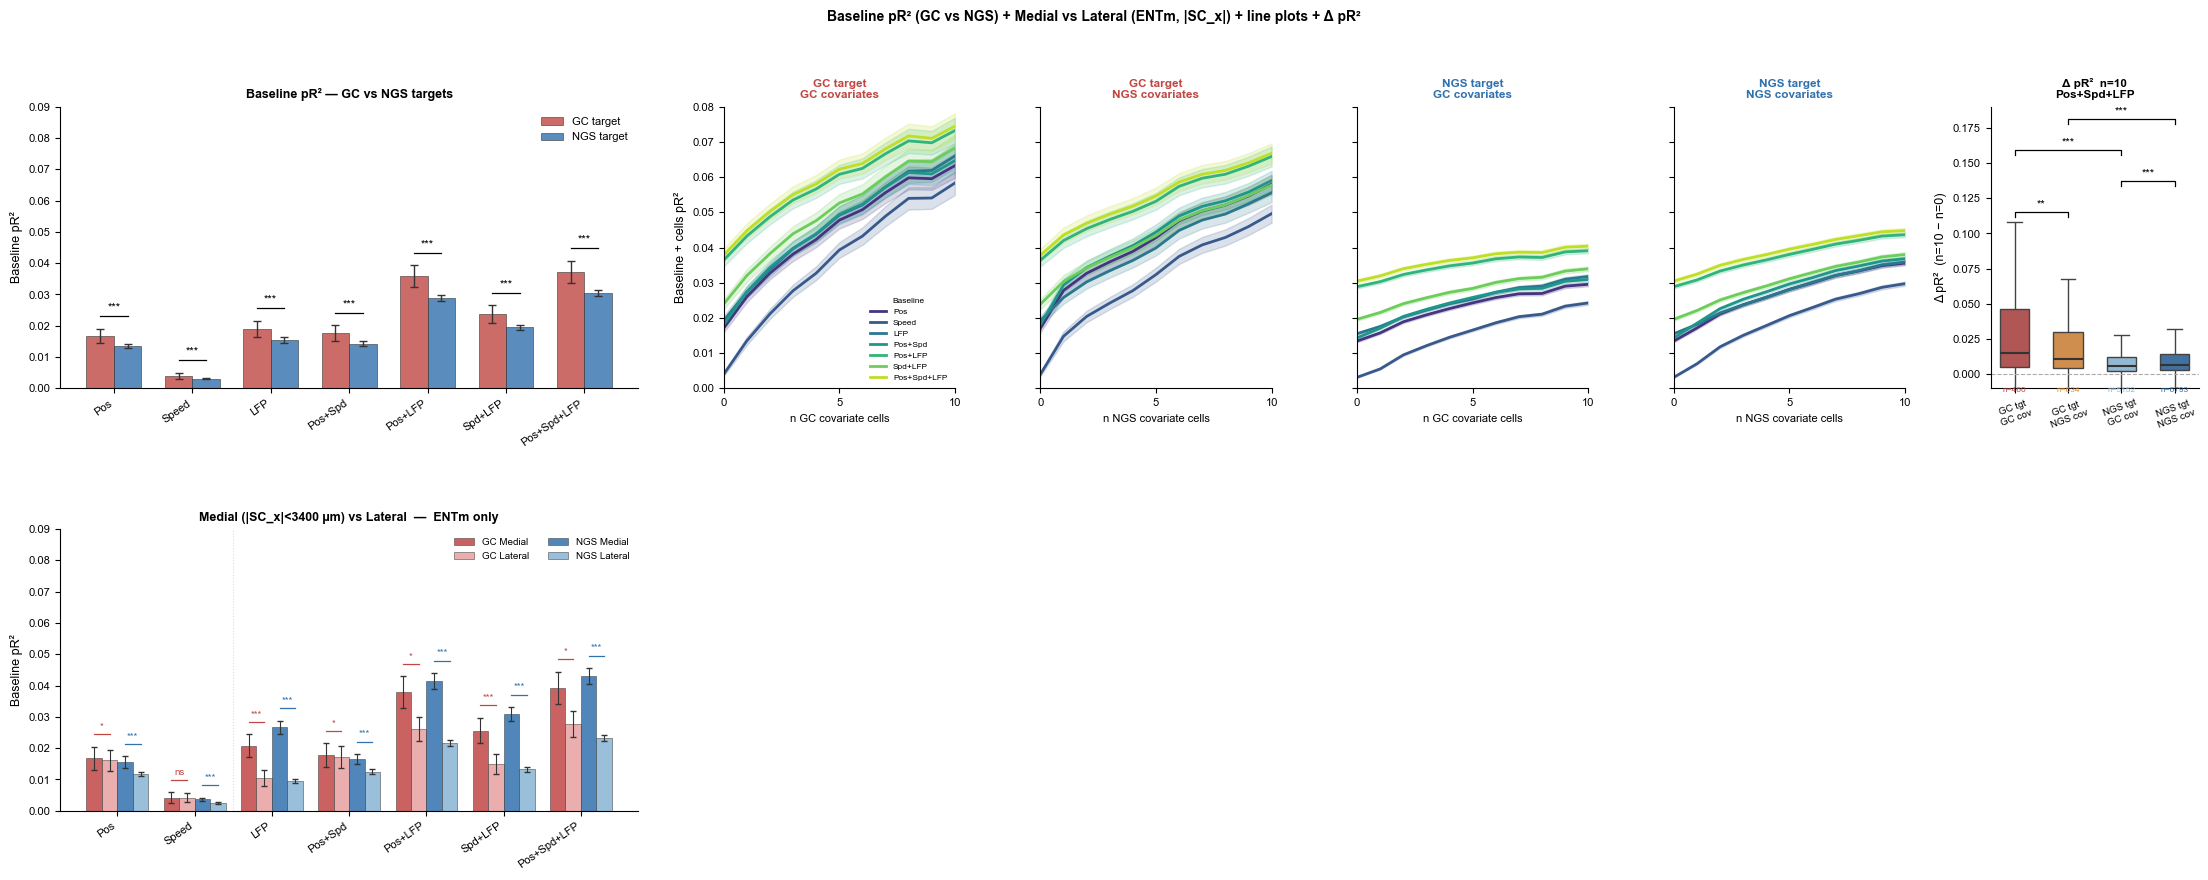

Saved


In [62]:
from scipy import stats as sp_stats

# ── Medial / lateral classification via |SC_x| (ENTm cells only) ──────────────
ML_THRESH = 3400   # µm

cc_pos = pd.read_csv(
    '/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv',
    usecols=['mouse', 'day', 'cluster_id', 'SC_x', 'brain_region']
).rename(columns={'cluster_id': 'target_cluster_id'})
cc_pos = cc_pos[cc_pos['brain_region'].str.startswith('ENTm')].copy()
cc_pos['ml_pos'] = cc_pos['SC_x'].abs()
print(f'ENTm cells: {len(cc_pos)}  |  |SC_x| range: {cc_pos["ml_pos"].min():.0f}–{cc_pos["ml_pos"].max():.0f} µm')

n0_combined = n0_all.drop_duplicates(
    subset=['mouse','day','target_cluster_id','baseline','covariate_cell_type']
).merge(cc_pos[['mouse','day','target_cluster_id','ml_pos']],
        on=['mouse','day','target_cluster_id'], how='left')

n0_combined['ml_group'] = n0_combined['ml_pos'].apply(
    lambda y: 'Medial' if pd.notna(y) and y < ML_THRESH else
              'Lateral' if pd.notna(y) else np.nan)
print(n0_combined['ml_group'].value_counts().to_dict())

# ── Colours ───────────────────────────────────────────────────────────────────
COL_GC_MED  = '#c04744'
COL_GC_LAT  = '#e8a0a0'
COL_NGS_MED = '#3171ae'
COL_NGS_LAT = '#88b4d4'

# ── Helpers ───────────────────────────────────────────────────────────────────
def baseline_stats(n0_df, target_broad, cov_type=None):
    sub = n0_df[n0_df['target_broad'] == target_broad]
    if cov_type:
        sub = sub[sub['covariate_cell_type'] == cov_type]
    return sub.groupby('baseline')['pR2_cv'].agg(mean='mean', sem=lambda x: x.sem())\
              .reindex(BASELINE_ORDER)

def baseline_stats_ml(n0_df, target_broad, ml_group, cov_type=None):
    sub = n0_df[(n0_df['target_broad'] == target_broad) &
                (n0_df['ml_group']     == ml_group)]
    if cov_type:
        sub = sub[sub['covariate_cell_type'] == cov_type]
    return sub.groupby('baseline')['pR2_cv'].agg(mean='mean', sem=lambda x: x.sem())\
              .reindex(BASELINE_ORDER)

def ml_p(n0_df, target_broad, bl):
    med = n0_df[(n0_df['target_broad']==target_broad) &
                (n0_df['ml_group']=='Medial') &
                (n0_df['baseline']==bl)]['pR2_cv'].dropna()
    lat = n0_df[(n0_df['target_broad']==target_broad) &
                (n0_df['ml_group']=='Lateral') &
                (n0_df['baseline']==bl)]['pR2_cv'].dropna()
    if len(med) < 3 or len(lat) < 3: return np.nan
    return sp_stats.mannwhitneyu(med, lat, alternative='two-sided').pvalue

def baseline_p(n0_df, bl):
    gc  = n0_df[(n0_df['target_broad']=='GC')  & (n0_df['baseline']==bl)]['pR2_cv'].dropna()
    ngs = n0_df[(n0_df['target_broad']=='NGS') & (n0_df['baseline']==bl)]['pR2_cv'].dropna()
    if len(gc) < 3 or len(ngs) < 3: return np.nan
    return sp_stats.mannwhitneyu(gc, ngs, alternative='two-sided').pvalue

def sig_star(p):
    if pd.isna(p):   return ''
    if p < 0.001:    return '***'
    if p < 0.01:     return '**'
    if p < 0.05:     return '*'
    return 'ns'

gc_stats  = baseline_stats(n0_combined, 'GC',  cov_type='GC')
ngs_stats = baseline_stats(n0_combined, 'NGS', cov_type='NGS')
pvals_bl  = {bl: baseline_p(n0_combined, bl) for bl in BASELINE_ORDER}

gc_med_stats  = baseline_stats_ml(n0_combined, 'GC',  'Medial',  cov_type='GC')
gc_lat_stats  = baseline_stats_ml(n0_combined, 'GC',  'Lateral', cov_type='GC')
ngs_med_stats = baseline_stats_ml(n0_combined, 'NGS', 'Medial',  cov_type='NGS')
ngs_lat_stats = baseline_stats_ml(n0_combined, 'NGS', 'Lateral', cov_type='NGS')
pvals_gc_ml   = {bl: ml_p(n0_combined, 'GC',  bl) for bl in BASELINE_ORDER}
pvals_ngs_ml  = {bl: ml_p(n0_combined, 'NGS', bl) for bl in BASELINE_ORDER}

# ── Layout: 2 rows × 6 columns (regular subplots) ────────────────────────────
# Row 0: GC vs NGS bars | 4 line plots | Δ pR² summary
# Row 1: medial/lateral bars | (cols 1-5 free for future additions)
W0 = 2.5 * 2

fig_D, axes = plt.subplots(
    2, 6,
    figsize=(22 + (W0 - 2.5) * 0.6, 8.8),
    gridspec_kw=dict(
        width_ratios=[W0, 2.0, 2.0, 2.0, 2.0, 1.8],
        hspace=0.50, wspace=0.30,
        left=0.06, right=0.97, top=0.90, bottom=0.10
    )
)

ax_bar       = axes[0, 0]   # GC vs NGS bars
ax_l_gc_gc   = axes[0, 1]   # line: GC→GC
ax_l_gc_ngs  = axes[0, 2]   # line: GC→NGS
ax_l_ngs_gc  = axes[0, 3]   # line: NGS→GC
ax_l_ngs_ngs = axes[0, 4]   # line: NGS→NGS
ax_dlt       = axes[0, 5]   # Δ pR² summary
ax_ml        = axes[1, 0]   # medial/lateral bars

# Hide empty bottom-row panels (cols 1-5 free for future use)
for col in range(1, 6):
    axes[1, col].set_visible(False)

CI_FAC = 1.96
x      = np.arange(len(BASELINE_ORDER))

# ── TOP BAR: GC vs NGS ────────────────────────────────────────────────────────
w = 0.35
ax_bar.bar(x - w/2, gc_stats['mean'],  yerr=CI_FAC*gc_stats['sem'],
           width=w, color=COL_GC,  alpha=0.80, edgecolor='#333', linewidth=0.5,
           error_kw=dict(elinewidth=1, capsize=3, ecolor='#333'), label='GC target')
ax_bar.bar(x + w/2, ngs_stats['mean'], yerr=CI_FAC*ngs_stats['sem'],
           width=w, color=COL_NGS, alpha=0.80, edgecolor='#333', linewidth=0.5,
           error_kw=dict(elinewidth=1, capsize=3, ecolor='#333'), label='NGS target')
ax_bar.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(BL_LABELS, rotation=35, ha='right', fontsize=8)
ax_bar.set_ylabel('Baseline pR²', fontsize=9)
ax_bar.set_ylim(0, 0.09)
ax_bar.set_title('Baseline pR² — GC vs NGS targets', fontsize=9, fontweight='bold')
ax_bar.legend(fontsize=8, frameon=False)
ax_bar.spines[['top','right']].set_visible(False)
ax_bar.tick_params(labelsize=8)

for xi, bl in enumerate(BASELINE_ORDER):
    star = sig_star(pvals_bl[bl])
    if not star: continue
    y_top = max(gc_stats.loc[bl,'mean']  + CI_FAC*gc_stats.loc[bl,'sem'],
                ngs_stats.loc[bl,'mean'] + CI_FAC*ngs_stats.loc[bl,'sem']) + 0.004
    ax_bar.plot([xi-w/2, xi+w/2], [y_top, y_top], color='k', lw=0.9)
    ax_bar.text(xi, y_top+0.001, star, ha='center', va='bottom', fontsize=8)

# ── BOTTOM BAR: Medial vs Lateral ─────────────────────────────────────────────
w4 = 0.20
offsets = [-1.5*w4, -0.5*w4, 0.5*w4, 1.5*w4]
bar_specs = [
    (gc_med_stats,  COL_GC_MED,  'GC Medial'),
    (gc_lat_stats,  COL_GC_LAT,  'GC Lateral'),
    (ngs_med_stats, COL_NGS_MED, 'NGS Medial'),
    (ngs_lat_stats, COL_NGS_LAT, 'NGS Lateral'),
]
for (stats, col, lbl), off in zip(bar_specs, offsets):
    ax_ml.bar(x + off, stats['mean'], yerr=CI_FAC*stats['sem'],
              width=w4, color=col, alpha=0.85, edgecolor='#333', linewidth=0.4,
              error_kw=dict(elinewidth=0.8, capsize=2, ecolor='#333'), label=lbl)

for xi, bl in enumerate(BASELINE_ORDER):
    star_gc = sig_star(pvals_gc_ml[bl])
    if star_gc:
        y_gc = max(gc_med_stats.loc[bl,'mean'] + CI_FAC*gc_med_stats.loc[bl,'sem'],
                   gc_lat_stats.loc[bl,'mean'] + CI_FAC*gc_lat_stats.loc[bl,'sem']) + 0.004
        ax_ml.plot([xi+offsets[0], xi+offsets[1]], [y_gc, y_gc], color=COL_GC_MED, lw=0.9)
        ax_ml.text(xi+(offsets[0]+offsets[1])/2, y_gc+0.001, star_gc,
                   ha='center', va='bottom', fontsize=7, color=COL_GC_MED)
    star_ngs = sig_star(pvals_ngs_ml[bl])
    if star_ngs:
        y_ngs = max(ngs_med_stats.loc[bl,'mean'] + CI_FAC*ngs_med_stats.loc[bl,'sem'],
                    ngs_lat_stats.loc[bl,'mean'] + CI_FAC*ngs_lat_stats.loc[bl,'sem']) + 0.004
        ax_ml.plot([xi+offsets[2], xi+offsets[3]], [y_ngs, y_ngs], color=COL_NGS_MED, lw=0.9)
        ax_ml.text(xi+(offsets[2]+offsets[3])/2, y_ngs+0.001, star_ngs,
                   ha='center', va='bottom', fontsize=7, color=COL_NGS_MED)

ax_ml.axhline(0, color='k', lw=0.7, ls='--', alpha=0.5)
ax_ml.axvline(1.5, color='#cccccc', lw=0.8, ls=':', alpha=0.7)
ax_ml.set_xticks(x); ax_ml.set_xticklabels(BL_LABELS, rotation=35, ha='right', fontsize=8)
ax_ml.set_ylabel('Baseline pR²', fontsize=9)
ax_ml.set_ylim(0, 0.09)
ax_ml.set_title(f'Medial (|SC_x|<{ML_THRESH} µm) vs Lateral  —  ENTm only',
                fontsize=9, fontweight='bold')
ax_ml.legend(fontsize=7, frameon=False, ncol=2)
ax_ml.spines[['top','right']].set_visible(False)
ax_ml.tick_params(labelsize=8)

# ── Line panels (row 0, cols 1-4) ─────────────────────────────────────────────
def draw_line_D(ax, lp_df, target_label, cov_label_str, tgt_color):
    for bl in BASELINE_ORDER:
        sub = lp_df[lp_df['baseline'] == bl].sort_values('n_covariate_cells')
        if sub.empty: continue
        c = BL_PALETTE[bl]
        ax.plot(sub['n_covariate_cells'], sub['mean'], color=c, lw=2.0,
                label=BASELINE_LABEL[bl])
        ax.fill_between(sub['n_covariate_cells'],
                        sub['mean']-sub['sem'], sub['mean']+sub['sem'],
                        color=c, alpha=0.18)
    ax.set_xlim(0, MAX_N); ax.set_ylim(0, 0.08); ax.set_xticks([0, 5, 10])
    ax.set_xlabel(f'n {cov_label_str} covariate cells', fontsize=8)
    ax.set_ylabel('Baseline + cells pR²', fontsize=9)
    ax.set_title(f'{target_label} target\n{cov_label_str} covariates',
                 fontsize=8.5, color=tgt_color, fontweight='bold')
    ax.axhline(0, color='#cccccc', lw=0.6, ls=':')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(labelsize=8)

draw_line_D(ax_l_gc_gc,   lp_gc_gc,   'GC',  'GC',  COL_GC)
draw_line_D(ax_l_gc_ngs,  lp_gc_ngs,  'GC',  'NGS', COL_GC)
draw_line_D(ax_l_ngs_gc,  lp_ngs_gc,  'NGS', 'GC',  COL_NGS)
draw_line_D(ax_l_ngs_ngs, lp_ngs_ngs, 'NGS', 'NGS', COL_NGS)
for ax in [ax_l_gc_ngs, ax_l_ngs_gc, ax_l_ngs_ngs]:
    ax.set_ylabel(''); ax.set_yticklabels([])
ax_l_gc_gc.legend(fontsize=6, frameon=False, ncol=1, loc='lower right',
                  title='Baseline', title_fontsize=6)

# ── Δ pR² summary (row 0, col 5) ──────────────────────────────────────────────
label_short_order = [LABEL_MAP[g] for g in GROUP_ORDER]
sns.boxplot(data=summary_df, x='label_short', y='delta',
            order=label_short_order,
            palette={LABEL_MAP[g]: GROUP_COLOR[g] for g in GROUP_ORDER},
            width=0.55, showfliers=False,
            medianprops=dict(color='#333333', lw=1.5), ax=ax_dlt)
ax_dlt.axhline(0, color='#aaaaaa', lw=0.8, ls='--')
ax_dlt.set_ylim(-0.01, 0.19); ax_dlt.set_xlabel('')
ax_dlt.set_ylabel(f'Δ pR²  (n={MAX_N} − n=0)', fontsize=9)
ax_dlt.set_title(f'Δ pR²  n={MAX_N}\n{BASELINE_LABEL[MOST_COMPLEX_BL]}',
                 fontsize=8.5, fontweight='bold')
ax_dlt.tick_params(axis='x', labelsize=7, rotation=20)
ax_dlt.tick_params(axis='y', labelsize=8)
ax_dlt.spines[['top','right']].set_visible(False)

compare_pairs = [('GC→GC','GC→NGS'), ('NGS→GC','NGS→NGS'),
                 ('GC→GC','NGS→GC'), ('GC→NGS','NGS→NGS')]
y_bracket, step = 0.115, 0.022
for bi, (g1, g2) in enumerate(compare_pairs):
    x1 = label_short_order.index(LABEL_MAP[g1])
    x2 = label_short_order.index(LABEL_MAP[g2])
    d1 = summary_df[summary_df['label']==g1]['delta'].dropna()
    d2 = summary_df[summary_df['label']==g2]['delta'].dropna()
    if len(d1) < 3 or len(d2) < 3: continue
    p  = sp_stats.mannwhitneyu(d1, d2, alternative='two-sided').pvalue
    s  = sig_star(p)
    if not s: continue
    yb = y_bracket + bi * step
    ax_dlt.plot([x1,x1,x2,x2],[yb-0.003,yb,yb,yb-0.003], color='k', lw=0.9)
    ax_dlt.text((x1+x2)/2, yb+0.002, s, ha='center', va='bottom', fontsize=8)
for xi, grp in enumerate(GROUP_ORDER):
    n = len(summary_df[summary_df['label']==grp])
    ax_dlt.text(xi, -0.009, f'n={n}', ha='center', va='top',
                fontsize=6, color=GROUP_COLOR[grp])

fig_D.suptitle(
    'Baseline pR² (GC vs NGS) + Medial vs Lateral (ENTm, |SC_x|) + line plots + Δ pR²',
    fontsize=10, fontweight='bold', y=1.01
)
fig_D.savefig(os.path.join(out_dir, 'Figure4_v4_altD_grouped_bars_lines.pdf'),
              bbox_inches='tight', dpi=300)
plt.show()
print('Saved')